# Mango Fruit Disease detection model

## Import Libraries

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.image import imread
from PIL import Image
import tensorflow as tf
from keras.preprocessing import image
from tensorflow.keras.utils import img_to_array, array_to_img
from keras.models import Sequential
from tensorflow import keras
from keras.layers import Conv2D,MaxPooling2D,Activation,Flatten,Dense,Dropout
from tensorflow.keras import layers
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [75]:
print(tf.__version__)

2.20.0


## create a dataset

In [76]:
batch_size = 32
img_height = 180
img_width = 180

# Split training folder into train and validation
train_image_dataset = tf.keras.utils.image_dataset_from_directory(
    "mango_dataset/train/",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_image_dataset = tf.keras.utils.image_dataset_from_directory(
    "mango_dataset/train/",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Test dataset (NO SPLIT HERE)
test_image_dataset = tf.keras.utils.image_dataset_from_directory(
    "mango_dataset/test/",
    image_size=(img_height, img_width),
    batch_size=batch_size
)


class_names = train_image_dataset.class_names
num_classes = len(class_names)
class_name = {}
for i in range(len(class_names)):
    class_name[i + 1] = class_names[i]

print(class_names)
print(class_name)

Found 619 files belonging to 5 classes.
Using 496 files for training.
Found 619 files belonging to 5 classes.
Using 123 files for validation.
Found 249 files belonging to 5 classes.
['Alternaria', 'Anthracnose', 'Black_Mould_Rot', 'Healthy', 'Stem_and_Rot']
{1: 'Alternaria', 2: 'Anthracnose', 3: 'Black_Mould_Rot', 4: 'Healthy', 5: 'Stem_and_Rot'}


##  Visualize the data

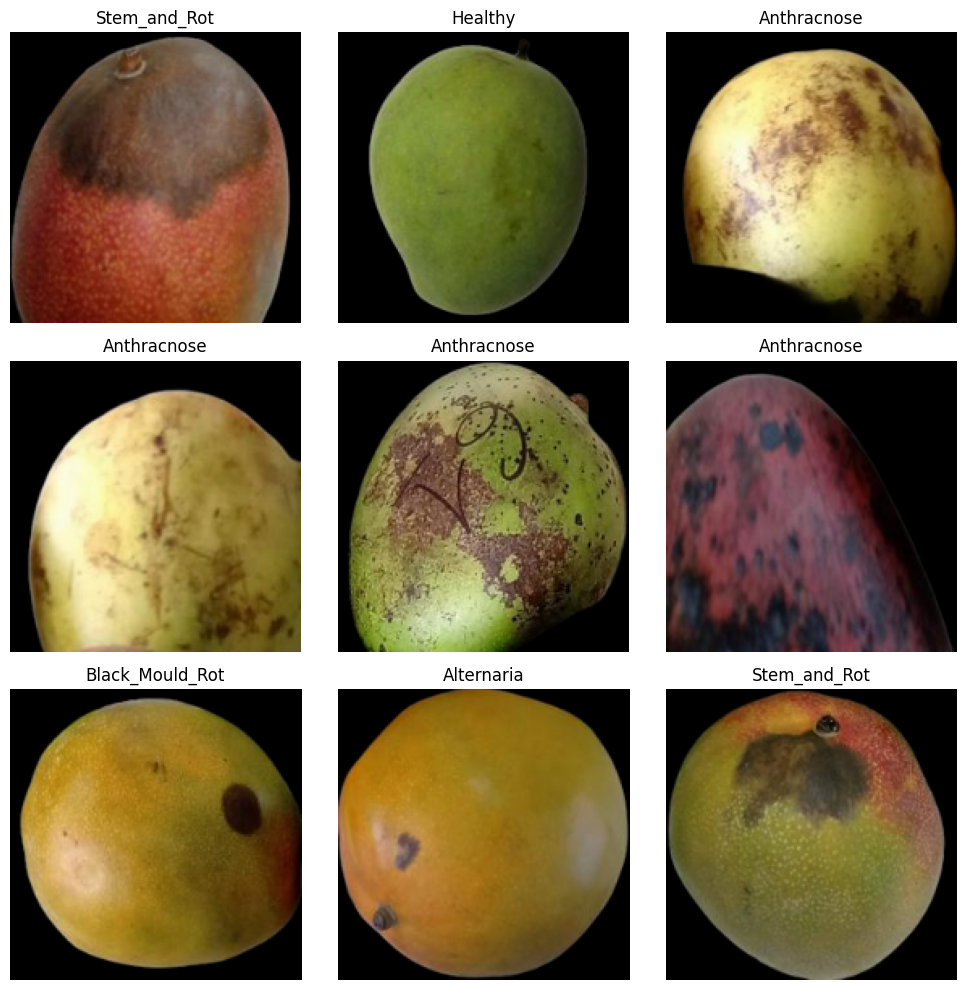

In [77]:
# Visualize the data (Fixed Version)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_image_dataset.take(1):  # Take only one batch
    for i in range(9):  # Show first 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()


In [78]:
image_batch, labels_batch = next(iter(train_image_dataset))
print(image_batch.shape)
print(labels_batch.shape)


(32, 180, 180, 3)
(32,)


##  creating CNN model

In [79]:
from tensorflow.keras import layers, Sequential
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

num_classes = len(class_names)

# 1️⃣ Load base model FIRST
base_model = MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

# 2️⃣ Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.3),
    layers.RandomContrast(0.2),
])

# 3️⃣ Build final model
model = Sequential([
    layers.Input(shape=(img_height, img_width, 3)),
    data_augmentation,
    layers.Lambda(preprocess_input),

    base_model,   # ✅ Now it exists

    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

C:\Users\divye\AppData\Local\Temp\ipykernel_18960\4202398992.py:8: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


##  compile the model

In [80]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [81]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 6, 6, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,592,325 (9.89 MB)

 Trainable params: 331,781 (1.27 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

##  Train the model

In [82]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

epochs = 30

history = model.fit(
    train_image_dataset,
    validation_data=val_image_dataset,
    epochs=epochs,
    callbacks=[early_stop]
)


Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 500ms/step - accuracy: 0.3085 - loss: 2.0752 - val_accuracy: 0.4553 - val_loss: 1.2562
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 414ms/step - accuracy: 0.4798 - loss: 1.5275 - val_accuracy: 0.5122 - val_loss: 1.0614
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 409ms/step - accuracy: 0.5544 - loss: 1.2854 - val_accuracy: 0.6341 - val_loss: 0.9084
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 407ms/step - accuracy: 0.6310 - loss: 1.0449 - val_accuracy: 0.6911 - val_loss: 0.8116
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 422ms/step - accuracy: 0.6956 - loss: 0.8992 - val_accuracy: 0.6992 - val_loss: 0.7430
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 409ms/step - accuracy: 0.6895 - loss: 0.8916 - val_accuracy: 0.7236 - val_loss: 0.6899
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 392ms/step - accuracy: 0.7077 - loss: 0.8013 - val_accuracy: 0.7398 - val_loss: 0.6509
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 403ms/step - accuracy: 0.7157 - loss: 0.7946 - val_accuracy: 0

Fine Tuning

In [83]:
# -------- Fine Tuning -------- #

# Unfreeze base model
base_model.trainable = True

# Freeze first layers, train last 40 layers
for layer in base_model.layers[:-40]:
    layer.trainable = False

Recompile

In [84]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Fine Tune Training

In [85]:
history_fine = model.fit(
    train_image_dataset,
    validation_data=val_image_dataset,
    epochs=8,
    callbacks=[early_stop]
)

Epoch 1/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 27s 814ms/step - accuracy: 0.5867 - loss: 1.0165 - val_accuracy: 0.8699 - val_loss: 0.4446
Epoch 2/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 667ms/step - accuracy: 0.6169 - loss: 1.0049 - val_accuracy: 0.8618 - val_loss: 0.4628
Epoch 3/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 635ms/step - accuracy: 0.6411 - loss: 0.9894 - val_accuracy: 0.8455 - val_loss: 0.4819
Epoch 4/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 624ms/step - accuracy: 0.6472 - loss: 1.0097 - val_accuracy: 0.8537 - val_loss: 0.5024
Epoch 5/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 679ms/step - accuracy: 0.6895 - loss: 0.8417 - val_accuracy: 0.8211 - val_loss: 0.5214


Evaluation cell

In [86]:
test_loss, test_accuracy = model.evaluate(val_image_dataset)

print("Validation Accuracy:", test_accuracy)
print("Validation Loss:", test_loss)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 357ms/step - accuracy: 0.8699 - loss: 0.4446
Validation Accuracy: 0.869918704032898
Validation Loss: 0.44464311003685


##  Predict the new data

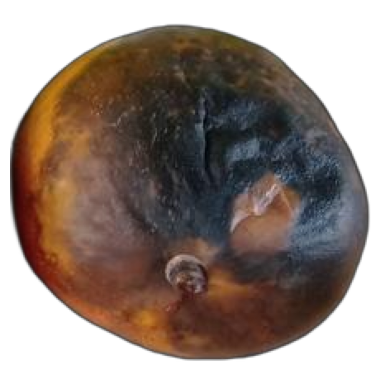

In [87]:
path = "mango_dataset/test/Stem_and_Rot/Lasiodiplodia_111.jpg"

img = imread(path)
plt.imshow(img)
plt.axis('off')
plt.show()


In [88]:
# predict the output

# path = "Cat_Dog/test/cats/cat_1.jpg"

img = image.load_img(path,target_size=(img_height,img_width))
img = image.img_to_array(img)
img = np.expand_dims(img,axis=0)
# img = preprocess_input(img)

prediction = model.predict(img)

predicted_class = np.argmax(prediction)
confidence = np.max(prediction) * 100

print("\n🍋 Mango Disease Detection Result")
print("----------------------------------")
print(f"Predicted Disease : {class_names[predicted_class]}")
print(f"Confidence        : {confidence:.2f}%")




1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

🍋 Mango Disease Detection Result
----------------------------------
Predicted Disease : Stem_and_Rot
Confidence        : 99.87%


In [89]:
# Define the path where you want to save the model

model.save('Mango_Fruit_Detection_Model.h5')


In [90]:
df = pd.read_csv("mango_dataset/Mango_fruit_dataset.csv")
df = df.replace('',np.nan)
df = df.dropna(axis="columns",how="any")


In [91]:

Sn_no, Disease_Type, Severity, Location_Date ,Description ,Symptoms  ,Diagnosis ,Precautions = df.loc[predicted_class,:]

print("\n\n ******  Mango Fruit Disease Detection ******* \n")
print(f"Disease Type : {Disease_Type}\nSeverity : {Severity}\nDescription : {Description}\nSymptoms : {Symptoms}\nDiagnosis : {Diagnosis}\nPrecautions : {Precautions}")



 ******  Mango Fruit Disease Detection ******* 

Disease Type : Steam and root
Severity : Mild, Moderate, Severe
Description : A fungal disease that causes the roots of mango trees to rot.
Symptoms : Symptoms include wilting, yellowing, and defoliation.
Diagnosis : Microscopic examination of the fungal spores is necessary for diagnosis.
Precautions : Apply fungicides to the soil around the tree. Avoid overwatering.


In [92]:
test_loss, test_accuracy = model.evaluate(val_image_dataset)

print("Validation Accuracy:", test_accuracy)
print("Validation Loss:", test_loss)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 319ms/step - accuracy: 0.8699 - loss: 0.4446
Validation Accuracy: 0.869918704032898
Validation Loss: 0.44464311003685
